# Estacionariedad y diferenciación

¿Qué pasa si una serie es NO estacionaria? ¿Quiere decir que NO podemos usar ARIMA?

¡Sí podemos usarlo! En la práctica podemos usar un truco que es la **diferenciación**

## 1. ¿Qué es la diferenciación?

<div class="alert alert-block alert-success"> Consiste en calcular <strong>diferencias entre observaciones consecutivas</strong> en la serie de tiempo </div>

## 2. Tipos de diferenciación

### 2.1. Diferenciación de primer grado

> Se calcula simplemente la diferencia entre observaciones consecutivas

$$ y'_t = y_t - y_{t-1}$$

Comencemos importando las librerías necesarias:

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import kpss # <--- Prueba de estacionariedad

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

Y ahora leamos un set de datos que contiene el comportamiento histórico de la acción de Google:

In [2]:
df = pd.read_csv('datos/accion_google.csv', parse_dates=["ds"])
df

,unique_id,ds,y
0,Google_cierre,2014-01-02,552.963501
1,Google_cierre,2014-01-03,548.929749
2,Google_cierre,2014-01-06,555.049927
3,Google_cierre,2014-01-07,565.750366
4,Google_cierre,2014-01-08,566.927673
...,...,...,...
1253,Google_cierre,2018-12-24,976.219971
1254,Google_cierre,2018-12-26,1039.459961
1255,Google_cierre,2018-12-27,1043.880005
1256,Google_cierre,2018-12-28,1037.079956


Veamos el comportamiento en el tiempo de esta Serie, con lo cual podremos verificar que NO es estacionaria:

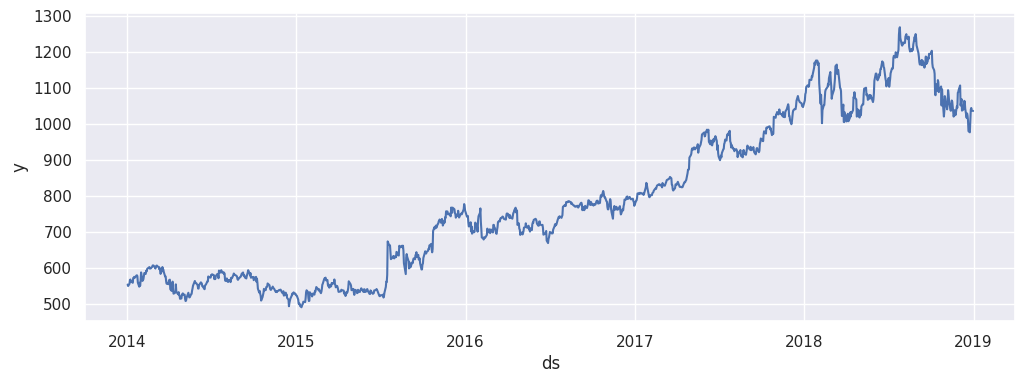

In [3]:
sns.lineplot(df, x="ds", y="y");

Ahora calculemos diferencias de primer orden:

In [4]:
# Calcular diferencias de primer orden
df["1diff"] = df["y"].diff()
df

,unique_id,ds,y,1diff
0,Google_cierre,2014-01-02,552.963501,NaN
1,Google_cierre,2014-01-03,548.929749,-4.033752
2,Google_cierre,2014-01-06,555.049927,6.120178
3,Google_cierre,2014-01-07,565.750366,10.700439
4,Google_cierre,2014-01-08,566.927673,1.177307
...,...,...,...,...
1253,Google_cierre,2018-12-24,976.219971,-3.320007
1254,Google_cierre,2018-12-26,1039.459961,63.239990
1255,Google_cierre,2018-12-27,1043.880005,4.420044
1256,Google_cierre,2018-12-28,1037.079956,-6.800049


Y grafiquemos la Serie para verificar que es estacionaria:

<Axes: xlabel='ds', ylabel='1diff'>

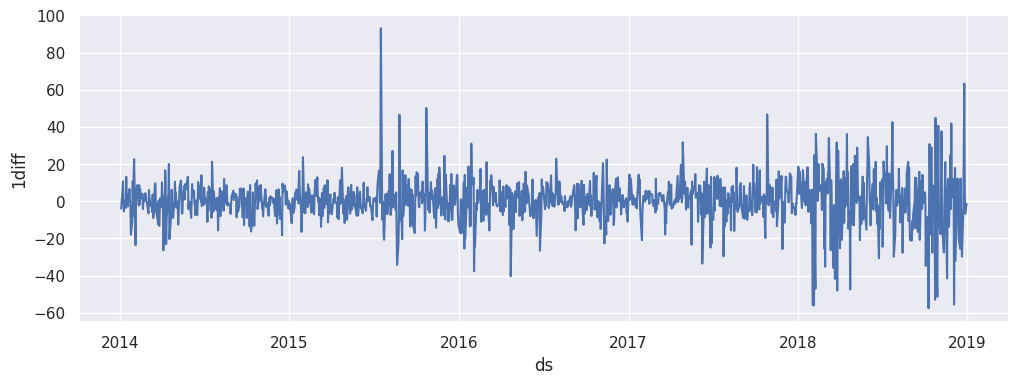

In [5]:
sns.lineplot(df, x="ds", y="1diff")

### 2.2. Diferenciación de segundo grado

En ocasiones la diferenciación de primer grado no es suficiente para hacer que la Serie sea estacional, así que podemos usar la diferenciación de segundo grado la cual:

> Se calcula simplemente calculando una vez más las diferencias de primer grado:

$$ y''_t = y'_t - y'_{t-1}$$

Y reemplazando los términos $y'_t$ y $y'_{t-1}$:

$$ y''_t = (y_t - y_{t-1}) - (y_{t-1} - y_{t-2})$$

Y reorganizando:

$$ y''_t = y_t - 2y_{t-1} + y_{t-2}$$

Veamos esto aplicado al ejemplo anterior:

In [6]:
df["2diff"] = df["1diff"].diff()
df

,unique_id,ds,y,1diff,2diff
0,Google_cierre,2014-01-02,552.963501,NaN,NaN
1,Google_cierre,2014-01-03,548.929749,-4.033752,NaN
2,Google_cierre,2014-01-06,555.049927,6.120178,10.153930
3,Google_cierre,2014-01-07,565.750366,10.700439,4.580261
4,Google_cierre,2014-01-08,566.927673,1.177307,-9.523132
...,...,...,...,...,...
1253,Google_cierre,2018-12-24,976.219971,-3.320007,26.549988
1254,Google_cierre,2018-12-26,1039.459961,63.239990,66.559997
1255,Google_cierre,2018-12-27,1043.880005,4.420044,-58.819946
1256,Google_cierre,2018-12-28,1037.079956,-6.800049,-11.220093


Y grafiquemos la Serie. Si originalmente la primera diferenciación produjo una Serie estacionaria, la segunda diferenciación preservará esta característica:

<Axes: xlabel='ds', ylabel='2diff'>

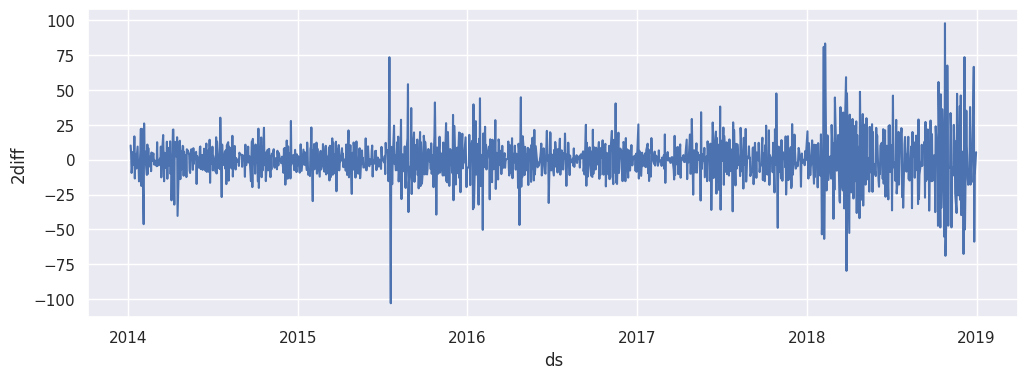

In [7]:
sns.lineplot(df, x="ds", y="2diff")

Aunque en este caso no era necesaria la segunda diferenciación, en todo caso podemos comprobar que la Serie resultante sigue siendo estacionaria.

### 2.3. Diferenciación estacional

Una Serie estacional es NO estacionaria. Pero podemos aplicar el mismo concepto anterior calculando **diferencias estacionales**. Si la estacionalidad de la serie es "m" (es decir se repite cada "m" registros) la diferencia estacional se define como:

$$y'_t = y_t - y_{t-m}$$

Veamos un ejemplo, leamos una Serie puramente estacional:

In [8]:
df_est = pd.read_csv('datos/serie_estacional.csv')
df_est

,unique_id,ds,y
0,estacional,0,2.522537
1,estacional,1,3.102779
2,estacional,2,3.403562
3,estacional,3,3.810553
4,estacional,4,3.818489
...,...,...,...
495,estacional,495,25.380009
496,estacional,496,25.683765
497,estacional,497,26.128090
498,estacional,498,26.355964


Y veamos su comportamiento en el tiempo:

<Axes: xlabel='ds', ylabel='y'>

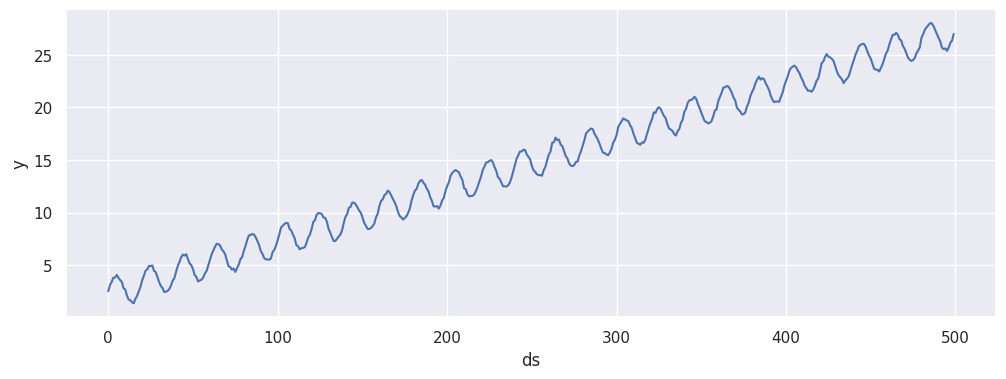

In [9]:
sns.lineplot(df_est, x="ds", y="y")

Ahora aplicamos diferencias estacionales (m=20):

In [10]:
# Aplicar diferencia estacional
df_est['diff_est'] = df_est["y"].diff(20)
df_est

,unique_id,ds,y,diff_est
0,estacional,0,2.522537,NaN
1,estacional,1,3.102779,NaN
2,estacional,2,3.403562,NaN
3,estacional,3,3.810553,NaN
4,estacional,4,3.818489,NaN
...,...,...,...,...
495,estacional,495,25.380009,0.878573
496,estacional,496,25.683765,0.988672
497,estacional,497,26.128090,0.966065
498,estacional,498,26.355964,0.951823


Si graficamos la Serie resultante podemos ver que es una serie estacionaria:

<Axes: xlabel='ds', ylabel='diff_est'>

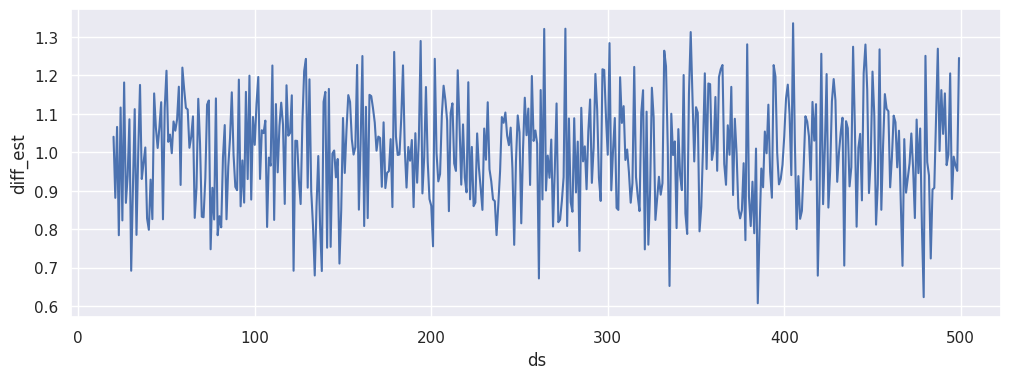

In [11]:
sns.lineplot(df_est, x="ds", y="diff_est")

Y se pueden incluso combinar diferencias de primer o segundo grado con diferencias estacionales para lograr que la Serie resultante sea estacionaria.

## 3. Pruebas de raíz unitaria

- Podemos aplicar pruebas estadísticas para determinar si la Serie es o no Estacionaria (y por tanto si se requiere o no diferenciación)
- Dos de los tests más usados son la prueba Dickey-Fuller (lección 5 curso Series de Tiempo Análisis Exploratorio) o el de Kwiatkowski-Phillips-Schmidt-Shin
- Test de Kwiatkowski-Phillips-Schmidt-Shin (KPSS):
    - Hipótesis nula: la Serie es estacionaria (p >= 0.05)
    - Hipótesis alterna: nos inclinamos por rechazar la hipótesis nula (p < 0.05) $\rightarrow$ la Serie es NO estacionaria $\rightarrow$ se requiere diferenciación
- **Importante: estos tests no siempre son confiables y no se sugiere confiar ciegamente en ellos**
    
Para aplicar esta prueba podemos usar la función "kpss()" importada anteriormente:

In [12]:
# Función para aplicar la prueba
def prueba_kpss(serie):
    # Eliminar posibles NaN de la serie
    serie = serie.dropna()

    # Aplicar prueba y mostrar resultado
    _, pval, *_ = kpss(serie)

    if pval<0.05:
        print(f"p = {pval} < 0.05")
        print("Se rechaza la hipótesis nula -> Serie NO estacionaria -> Se requiere diferenciación")
    else:
        print(f"p = {pval} >= 0.05")
        print("Nos inclinamos por la hipótesis nula -> Serie estacionaria -> NO se requiere diferenciación")

# Prueba para la Serie de la acción de Google
print("Serie acción de Google")
prueba_kpss(df["y"])

print("-"*20)
print("Serie acción de Google primera diferencia")
prueba_kpss(df["1diff"])

# Prueba para la Serie estacional
print("-"*20)
print("Serie estacional")
prueba_kpss(df_est["y"])

print("-"*20)
print("Serie estacional con diferencia estacional")
prueba_kpss(df_est["diff_est"])

Serie acción de Google
p = 0.01 < 0.05
Se rechaza la hipótesis nula -> Serie NO estacionaria -> Se requiere diferenciación
--------------------
Serie acción de Google primera diferencia
p = 0.1 >= 0.05
Nos inclinamos por la hipótesis nula -> Serie estacionaria -> NO se requiere diferenciación
--------------------
Serie estacional
p = 0.01 < 0.05
Se rechaza la hipótesis nula -> Serie NO estacionaria -> Se requiere diferenciación
--------------------
Serie estacional con diferencia estacional
p = 0.1 >= 0.05
Nos inclinamos por la hipótesis nula -> Serie estacionaria -> NO se requiere diferenciación


/tmp/ipykernel_59625/2093171592.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  _, pval, *_ = kpss(serie)
/tmp/ipykernel_59625/2093171592.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, pval, *_ = kpss(serie)
/tmp/ipykernel_59625/2093171592.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  _, pval, *_ = kpss(serie)
/tmp/ipykernel_59625/2093171592.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, pval, *_ = kpss(serie)


Observamos que para la Serie puramente estacional la prueba indica que es una serie estacionaria ¡cuando realmente no lo es!

## 4. El operador de retroceso (*backward shift operator*)

Algo de notación que en ocasiones resulta útil, pues permite escribir de manera más compacta ecuaciones que incluyan diferenciación:

- En lugar de escribir $y_{t-1}$ podemos escribir $By_t$
- El operador $B$ se conoce como el **operador de retroceso**

Por ejemplo, la diferenciación de primer grado:

$$ y'_t = y_t - y_{t-1}$$

se puede reescribir como:

$$ y'_t = y_t - By_t = (1-B)y_t$$

Y por ejemplo, la diferenciación de segundo grado:

$$ y''_t = y_t - 2y_{t-1} + y_{t-2}$$

se puede reescribir como:

$$ y''_t = y_t - 2By_t - B^2y_t = (1-2B-B^2)y_t = (1-B)^2y_t$$

Y generalizando, podemos escribir diferenciaciones de grado "d" como:

$$(1-B)^d y_t$$

Además, en el caso de diferencias estacionales:

$$y'_t = y_t - y_{t-m}$$

Podemos usar esta expresión equivalente:

$$y'_t = y_t - B^my_t = (1-B^m)y_t$$

